In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import metrics
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifier

from warnings import filterwarnings
filterwarnings('ignore')

## visualising the data

In [3]:
df=pd.read_csv("Bank_Transaction_Fraud_Detection.csv")
df.head(2)

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-null  object 
 14  Merc

- 4 numeric column 
- 20 catagorical column( in which 2 are time datatype)

In [6]:
print("number of rows :", df.shape[0])
print('number of columns :', df.shape[1])

number of rows : 200000
number of columns : 24


## null values

In [14]:
df.isna().sum()*100

Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64

- no null values

## check for duplicated rows in the data

In [11]:
df[df.duplicated()]

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email


- no duplicate rows

## changing datatype for datetime

In [14]:
df['year'] = pd.to_datetime(df['Transaction_Date']).dt.year
df['month'] = pd.to_datetime(df['Transaction_Date']).dt.month
df['day'] = pd.to_datetime(df['Transaction_Date']).dt.day
df['hour'] = pd.to_datetime(df['Transaction_Time'], format='%H:%M:%S').dt.hour
df['minute'] = pd.to_datetime(df['Transaction_Time'], format='%H:%M:%S').dt.minute
df['second'] = pd.to_datetime(df['Transaction_Time'], format='%H:%M:%S').dt.second

In [15]:
df.year.value_counts()

year
2025    200000
Name: count, dtype: int64

In [16]:
df.month.value_counts()

month
1    200000
Name: count, dtype: int64

In [17]:
df=df.drop(columns=['second','month','year','Transaction_Time','Transaction_Date','Customer_ID','Customer_Name','Transaction_ID','Merchant_ID','Transaction_Currency','Customer_Contact','Customer_Email'],axis=1)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Gender                   200000 non-null  object 
 1   Age                      200000 non-null  int64  
 2   State                    200000 non-null  object 
 3   City                     200000 non-null  object 
 4   Bank_Branch              200000 non-null  object 
 5   Account_Type             200000 non-null  object 
 6   Transaction_Amount       200000 non-null  float64
 7   Transaction_Type         200000 non-null  object 
 8   Merchant_Category        200000 non-null  object 
 9   Account_Balance          200000 non-null  float64
 10  Transaction_Device       200000 non-null  object 
 11  Transaction_Location     200000 non-null  object 
 12  Device_Type              200000 non-null  object 
 13  Is_Fraud                 200000 non-null  int64  
 14  Tran

## Seperate num and cat variables

In [20]:
num_col=df.select_dtypes(include=np.number).columns.to_list()
print(num_col)

['Age', 'Transaction_Amount', 'Account_Balance', 'Is_Fraud', 'day', 'hour', 'minute']


In [21]:
df_num=df.select_dtypes(include=np.number)
df_num.head()

,Age,Transaction_Amount,Account_Balance,Is_Fraud,day,hour,minute
0,60,32415.45,74557.27,0,23,16,4
1,51,43622.60,74622.66,0,11,17,14
2,20,63062.56,66817.99,0,25,3,9
3,57,14000.72,58177.08,0,19,12,27
4,43,18335.16,16108.56,0,30,18,30


In [22]:
cat_col=df.select_dtypes(include='object').columns.to_list()
print(cat_col)

['Gender', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Description']


In [23]:
df_cat=df.select_dtypes(include='object')
df_cat.head(2)

,Gender,State,City,Bank_Branch,Account_Type,Transaction_Type,Merchant_Category,Transaction_Device,Transaction_Location,Device_Type,Transaction_Description
0,Male,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,Transfer,Restaurant,Voice Assistant,"Thiruvananthapuram, Kerala",POS,Bitcoin transaction
1,Female,Maharashtra,Nashik,Nashik Branch,Business,Bill Payment,Restaurant,POS Mobile Device,"Nashik, Maharashtra",Desktop,Grocery delivery


In [24]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200000.0,44.015110,15.288774,18.00,31.000,44.000,57.000,70.00
Transaction_Amount,200000.0,49538.015554,28551.874004,10.29,24851.345,49502.440,74314.625,98999.98
Account_Balance,200000.0,52437.988784,27399.507128,5000.82,28742.395,52372.555,76147.670,99999.95
Is_Fraud,200000.0,0.050440,0.218852,0.00,0.000,0.000,0.000,1.00
day,200000.0,15.515985,8.672289,1.00,8.000,16.000,23.000,31.00
hour,200000.0,11.490420,6.917094,0.00,6.000,11.000,17.000,23.00
minute,200000.0,29.481920,17.285220,0.00,15.000,29.000,44.000,59.00


In [25]:
df_cat.describe().T

,count,unique,top,freq
Gender,200000,2,Male,100452
State,200000,34,Nagaland,6031
City,200000,145,Chandigarh,8135
Bank_Branch,200000,145,Chandigarh Branch,8135
Account_Type,200000,3,Checking,66924
Transaction_Type,200000,5,Credit,40180
Merchant_Category,200000,6,Restaurant,33525
Transaction_Device,200000,20,Self-service Banking Machine,21707
Transaction_Location,200000,148,"Kavaratti, Lakshadweep",5954
Device_Type,200000,4,POS,50111


## highly imbalanced data

- for numeric column

In [28]:
for i in num_col:
    if i not in ["Transaction_Amount","Account_Balance"]:
        print(f"Column: {i}")
        print(df[i].value_counts(normalize=True).sort_values(ascending=False) * 100)
        print("-----------------------------------------------")

Column: Age
Age
61    1.9645
42    1.9355
70    1.9320
39    1.9290
32    1.9285
56    1.9205
69    1.9200
23    1.9160
37    1.9145
30    1.9115
31    1.9105
24    1.9100
40    1.9090
26    1.9070
41    1.9060
28    1.9045
25    1.9020
62    1.9020
59    1.9005
50    1.8980
19    1.8980
52    1.8935
43    1.8935
51    1.8930
54    1.8930
58    1.8925
60    1.8895
36    1.8880
29    1.8875
68    1.8875
48    1.8865
33    1.8855
63    1.8830
65    1.8805
35    1.8790
46    1.8785
66    1.8690
38    1.8685
47    1.8670
45    1.8630
22    1.8610
34    1.8590
44    1.8570
18    1.8560
49    1.8500
67    1.8500
55    1.8480
57    1.8465
21    1.8455
64    1.8380
27    1.8365
53    1.8325
20    1.8220
Name: proportion, dtype: float64
-----------------------------------------------
Column: Is_Fraud
Is_Fraud
0    94.956
1     5.044
Name: proportion, dtype: float64
-----------------------------------------------
Column: day
day
29    3.4270
30    3.4125
20    3.4010
22    3.3920
2     3.3890
3 

In [29]:
for i in cat_col:
    if i not in ["Customer_ID", "Customer_Name", "Transaction_ID", "Transaction_Time", "Merchant_ID", "Customer_Contact", "Customer_Email"]:
        print(f"Column: {i}")
        print(df[i].value_counts(normalize=True).sort_values(ascending=False) * 100)
        print("----------------------------------------------------------------------------------------")

Column: Gender
Gender
Male      50.226
Female    49.774
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------
Column: State
State
Nagaland                                    3.0155
Meghalaya                                   3.0015
Uttar Pradesh                               3.0010
Uttarakhand                                 2.9925
Lakshadweep                                 2.9770
Telangana                                   2.9760
Haryana                                     2.9735
Delhi                                       2.9715
Kerala                                      2.9665
Madhya Pradesh                              2.9640
Arunachal Pradesh                           2.9595
Punjab                                      2.9560
Gujarat                                     2.9505
Odisha                                      2.9495
Jharkhand                                   2.9490
Mizoram                              

- Transaction_Currency (INR    100 %)

## Univariate analysis on numeric variable:

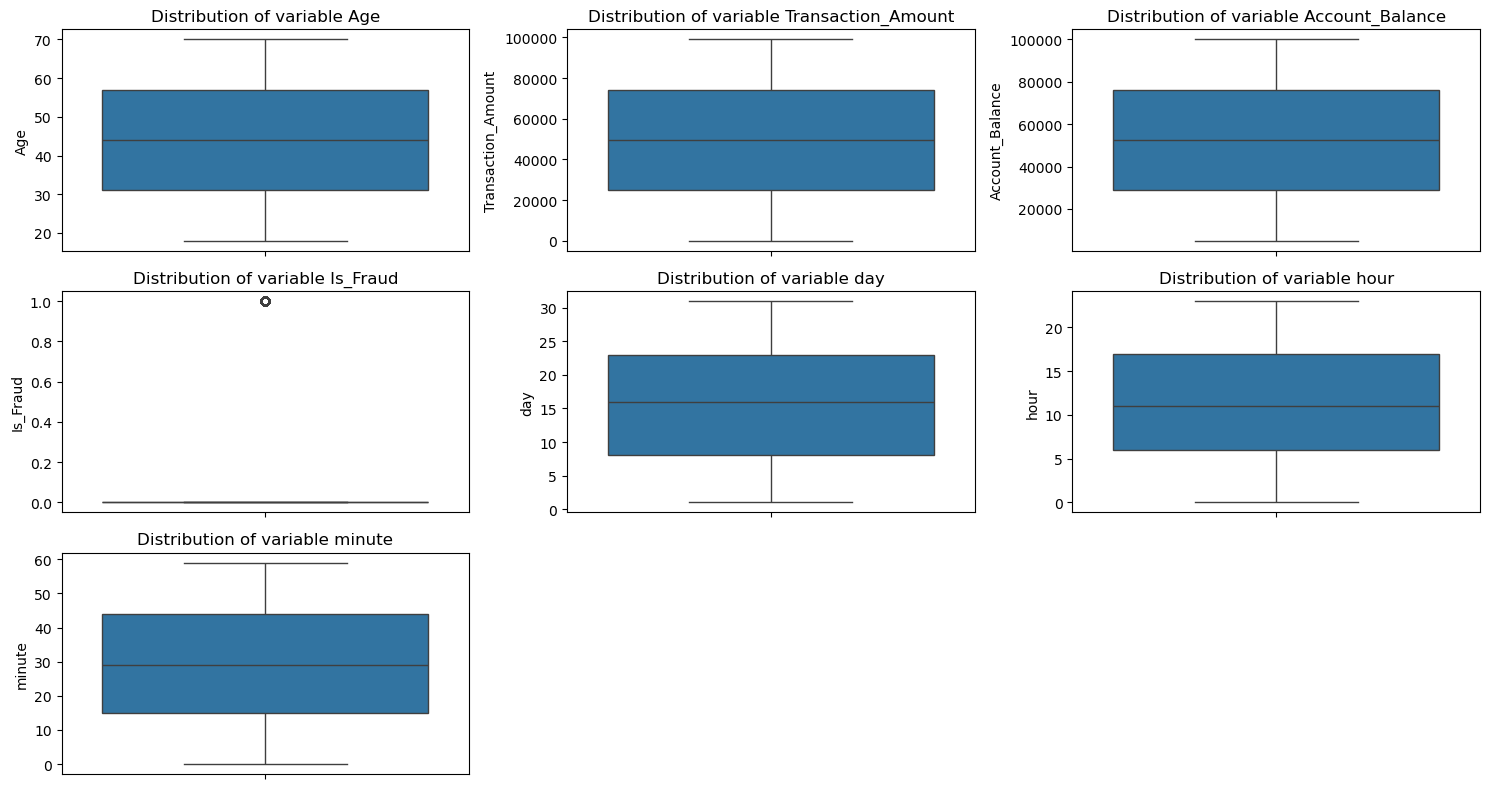

In [32]:
plt.rcParams['figure.figsize'] = [15,8]
t=1
for i in num_col:
    plt.subplot(3,3,t)
    sns.boxplot(df[i])
    plt.title(f'Distribution of variable {i}')
    t+=1
plt.tight_layout()
plt.show()

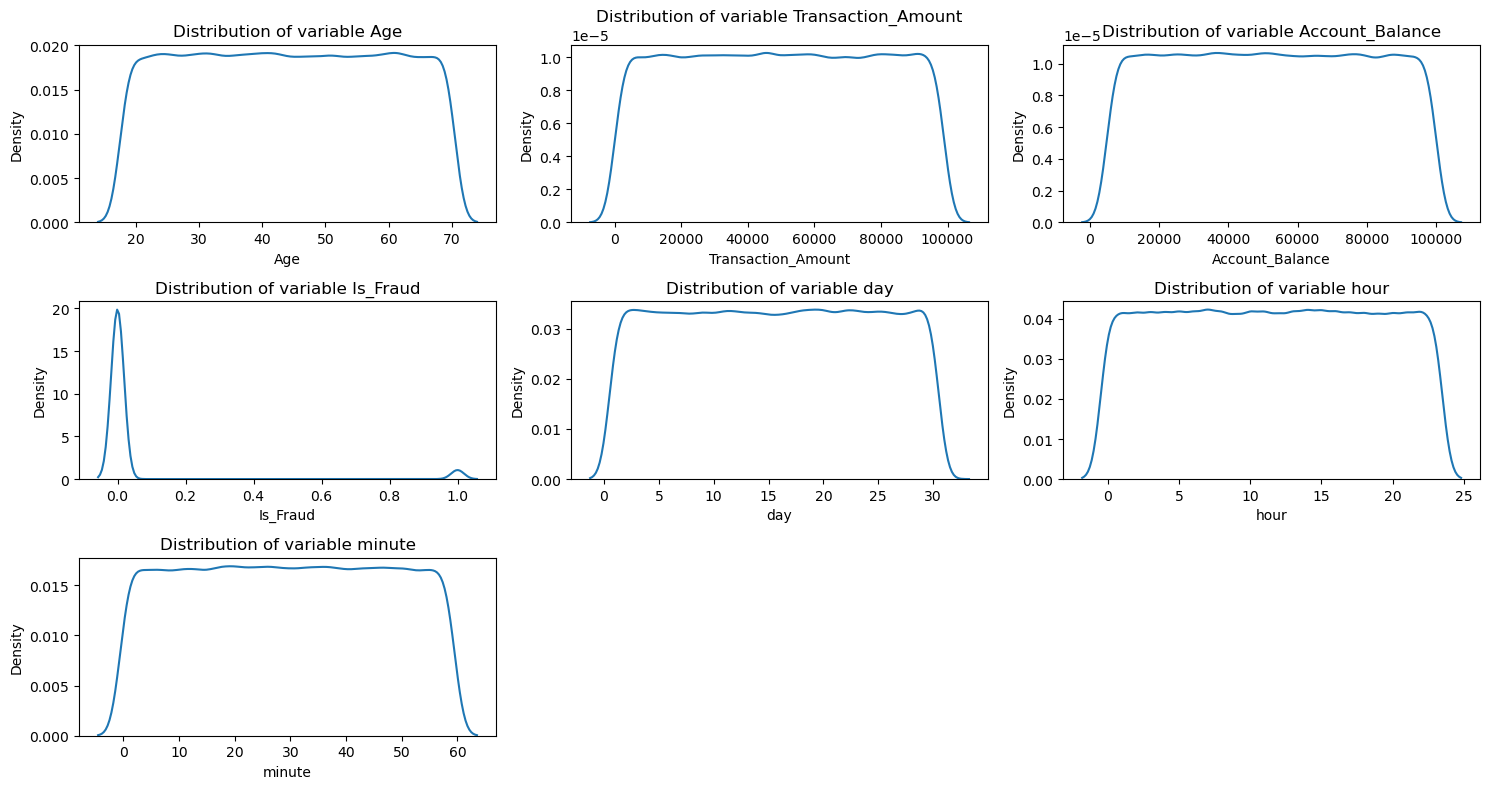

In [33]:
plt.rcParams['figure.figsize'] = [15,8]
t=1
for i in num_col:
    plt.subplot(3,3,t)
    sns.kdeplot(df[i])
    plt.title(f'Distribution of variable {i}')
    t+=1
plt.tight_layout()
plt.show()

In [34]:
df[num_col].skew() 

Age                   0.002644
Transaction_Amount   -0.000472
Account_Balance       0.003872
Is_Fraud              4.108395
day                  -0.002669
hour                  0.001420
minute               -0.000455
dtype: float64

In [35]:
df[num_col].kurt()

Age                   -1.200299
Transaction_Amount    -1.198195
Account_Balance       -1.197652
Is_Fraud              14.879057
day                   -1.204752
hour                  -1.201872
minute                -1.194665
dtype: float64

## Univariate analysis on catogarical variable:

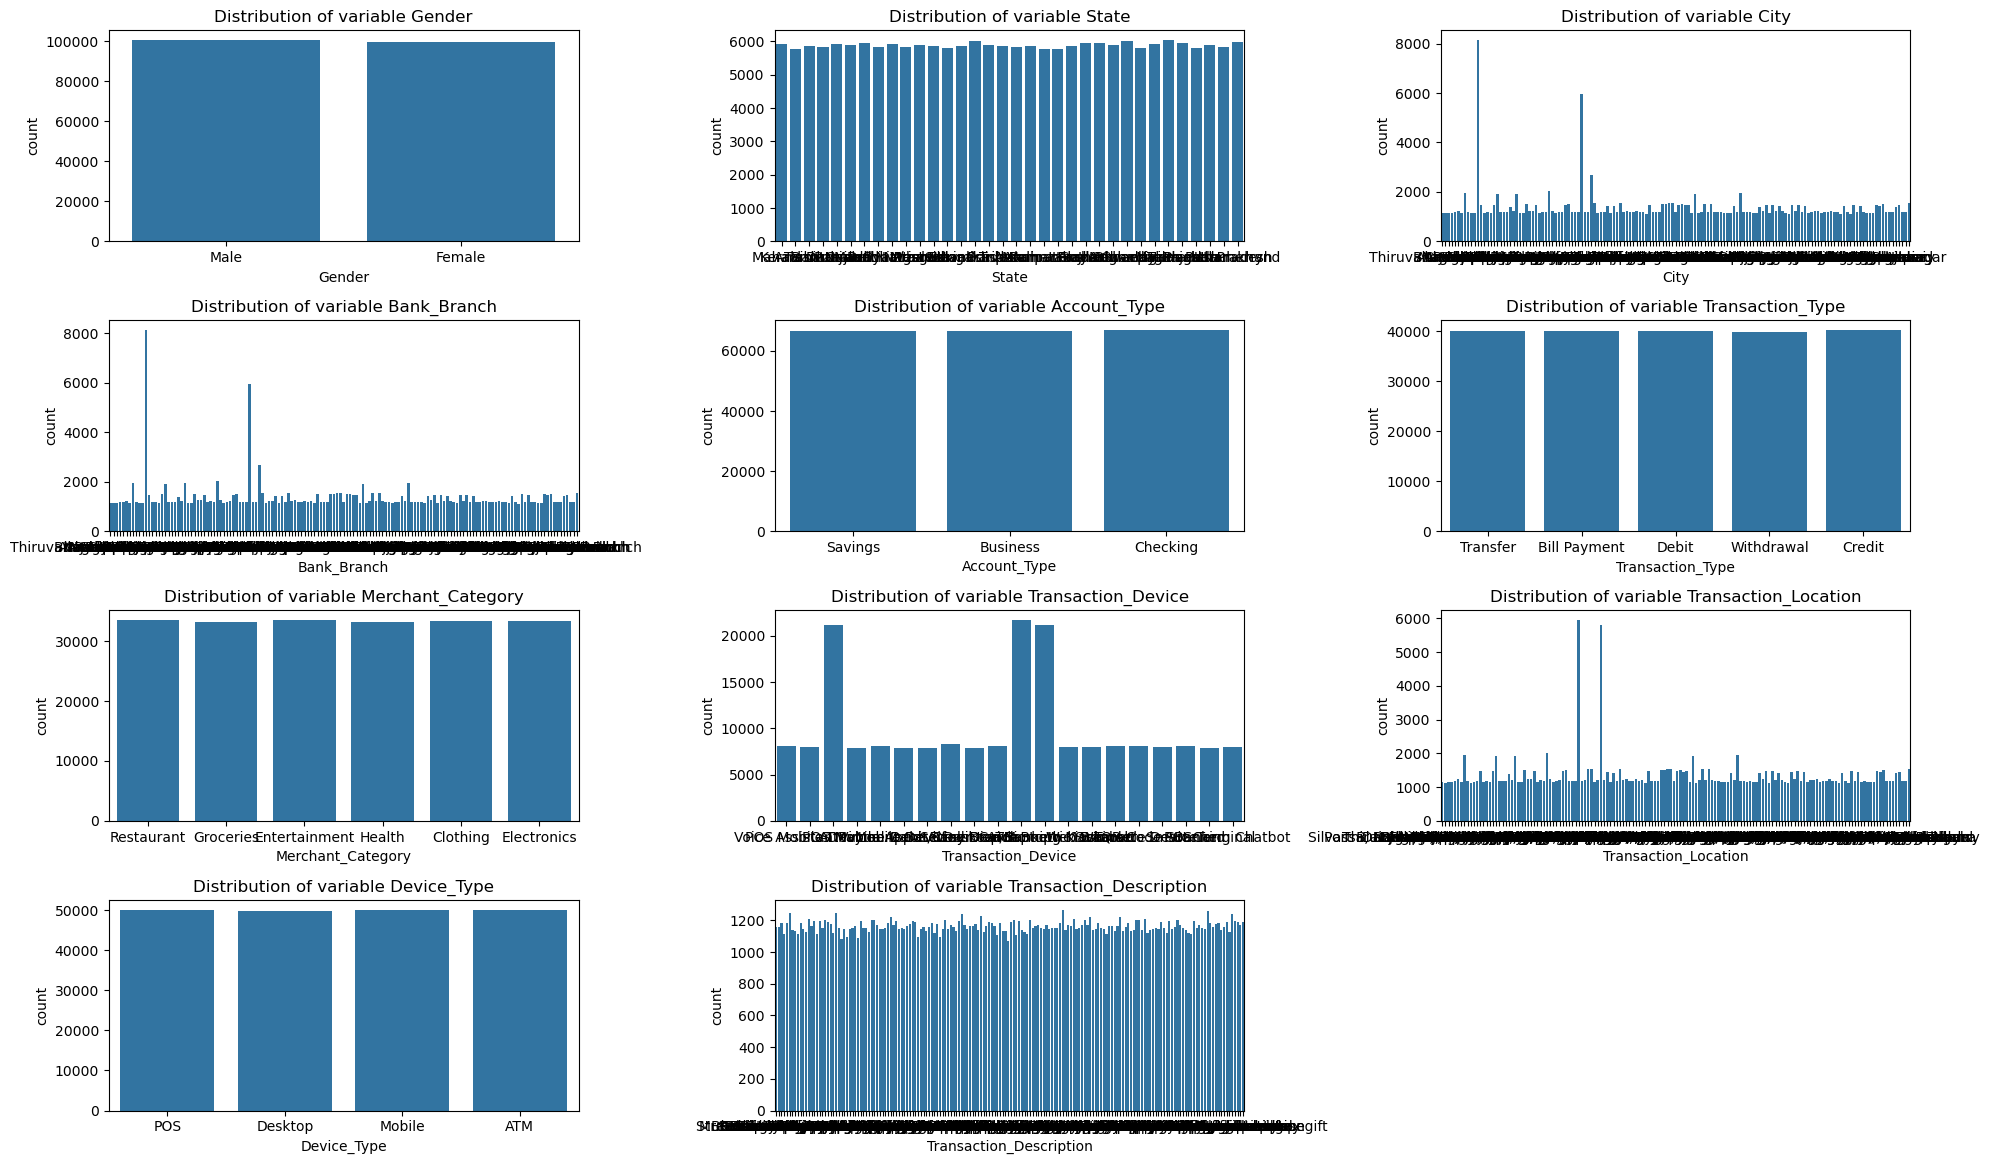

In [37]:
plt.rcParams['figure.figsize'] = [20,20]
t=1
for i in cat_col:
    if i not in "Transaction_Time":
        plt.subplot(7,3,t)
        sns.countplot(data=df,x=i)
        plt.title(f'Distribution of variable {i}')
        t+=1
plt.tight_layout()
plt.show()

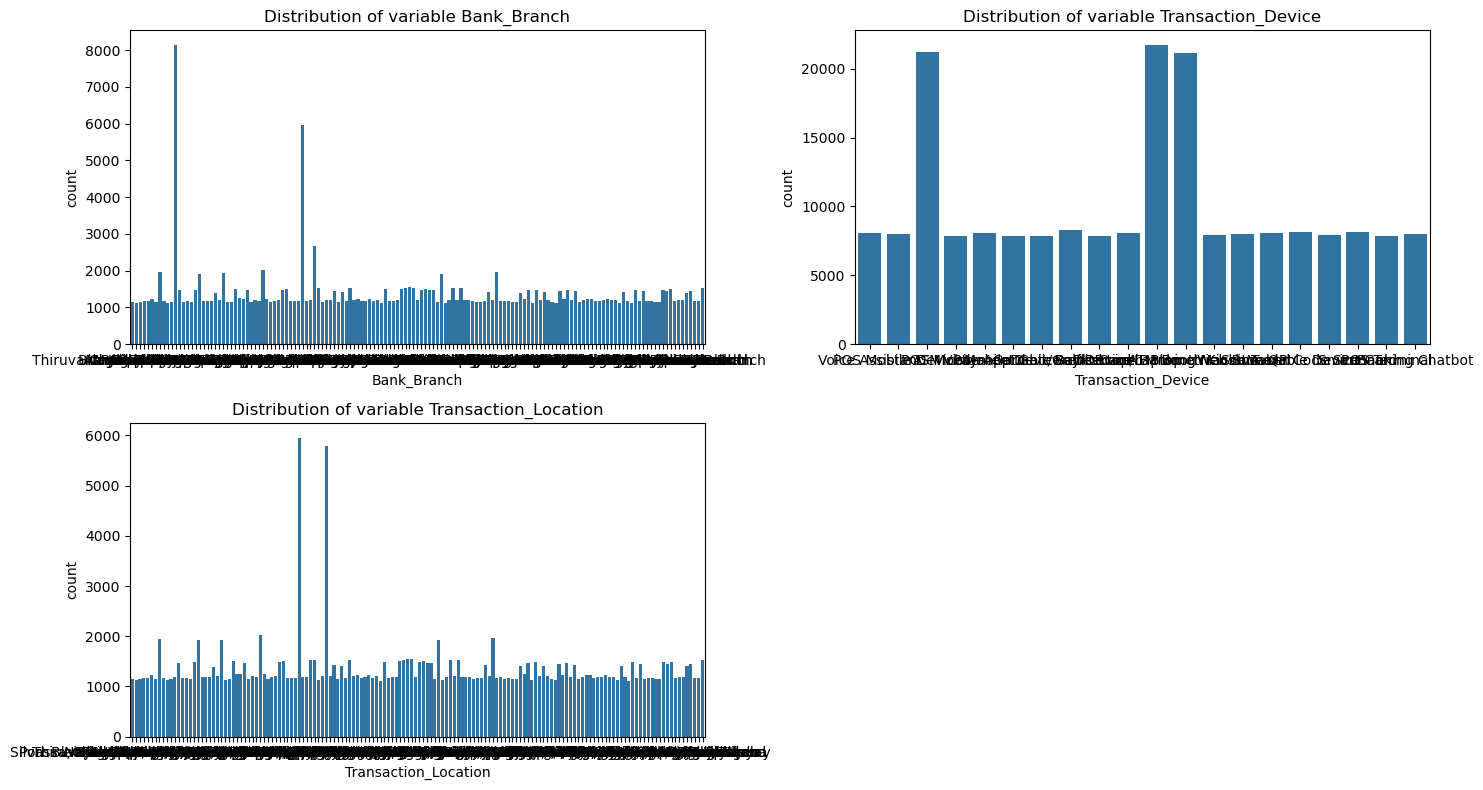

In [38]:
plt.rcParams['figure.figsize'] = [15,8]
t=1
for i in ['Bank_Branch','Transaction_Device','Transaction_Location']:
    plt.subplot(2,2,t)
    sns.countplot(data=df,x=i)
    plt.title(f'Distribution of variable {i}')
    t+=1
plt.tight_layout()
plt.show()

## bivariate analysis:

- Numerical vs Numerical

Age Is_Fraud
0    44.020457
1    43.914453
Name: Age, dtype: float64
-------------------------------------------------
Transaction_Amount Is_Fraud
0    49551.831380
1    49277.925242
Name: Transaction_Amount, dtype: float64
-------------------------------------------------
Account_Balance Is_Fraud
0    52437.197166
1    52452.891412
Name: Account_Balance, dtype: float64
-------------------------------------------------
day Is_Fraud
0    15.516255
1    15.510904
Name: day, dtype: float64
-------------------------------------------------
hour Is_Fraud
0    11.493544
1    11.431602
Name: hour, dtype: float64
-------------------------------------------------
minute Is_Fraud
0    29.477295
1    29.568993
Name: minute, dtype: float64
-------------------------------------------------


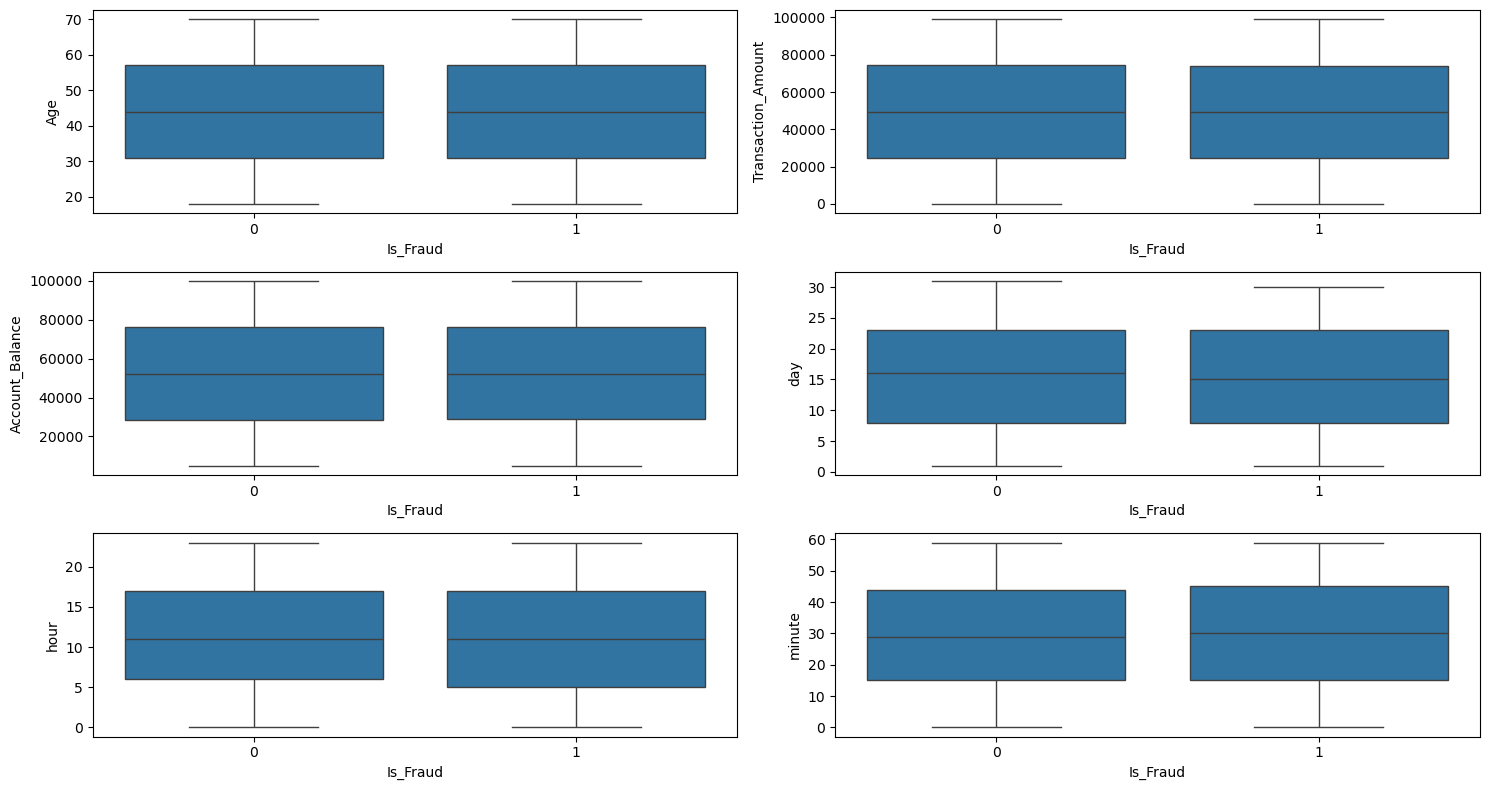

In [41]:
t=1
for i in num_col:
    if i != 'Is_Fraud':
        plt.subplot(3,2,t)
        sns.boxplot(x='Is_Fraud', y=i, data=df)
        print(f"{i}",df.groupby('Is_Fraud')[i].mean())
        print("-------------------------------------------------")
        t+=1
plt.tight_layout()
plt.show()

- Numeric vs Categoric

Gender Axes(0.125,0.825775;0.775x0.0542254)
Is_Fraud         0         1
Gender                      
Male      0.949419  0.050581
Female    0.949703  0.050297
-------------------------------------------------------------
State Axes(0.125,0.760704;0.775x0.0542254)
Is_Fraud                                         0         1
State                                                       
Tamil Nadu                                0.943845  0.056155
Lakshadweep                               0.944239  0.055761
Sikkim                                    0.946142  0.053858
Uttarakhand                               0.946700  0.053300
West Bengal                               0.946847  0.053153
Madhya Pradesh                            0.946862  0.053138
Mizoram                                   0.947047  0.052953
Telangana                                 0.947077  0.052923
Tripura                                   0.947521  0.052479
Karnataka                                 0.947532  0.052468
Dad

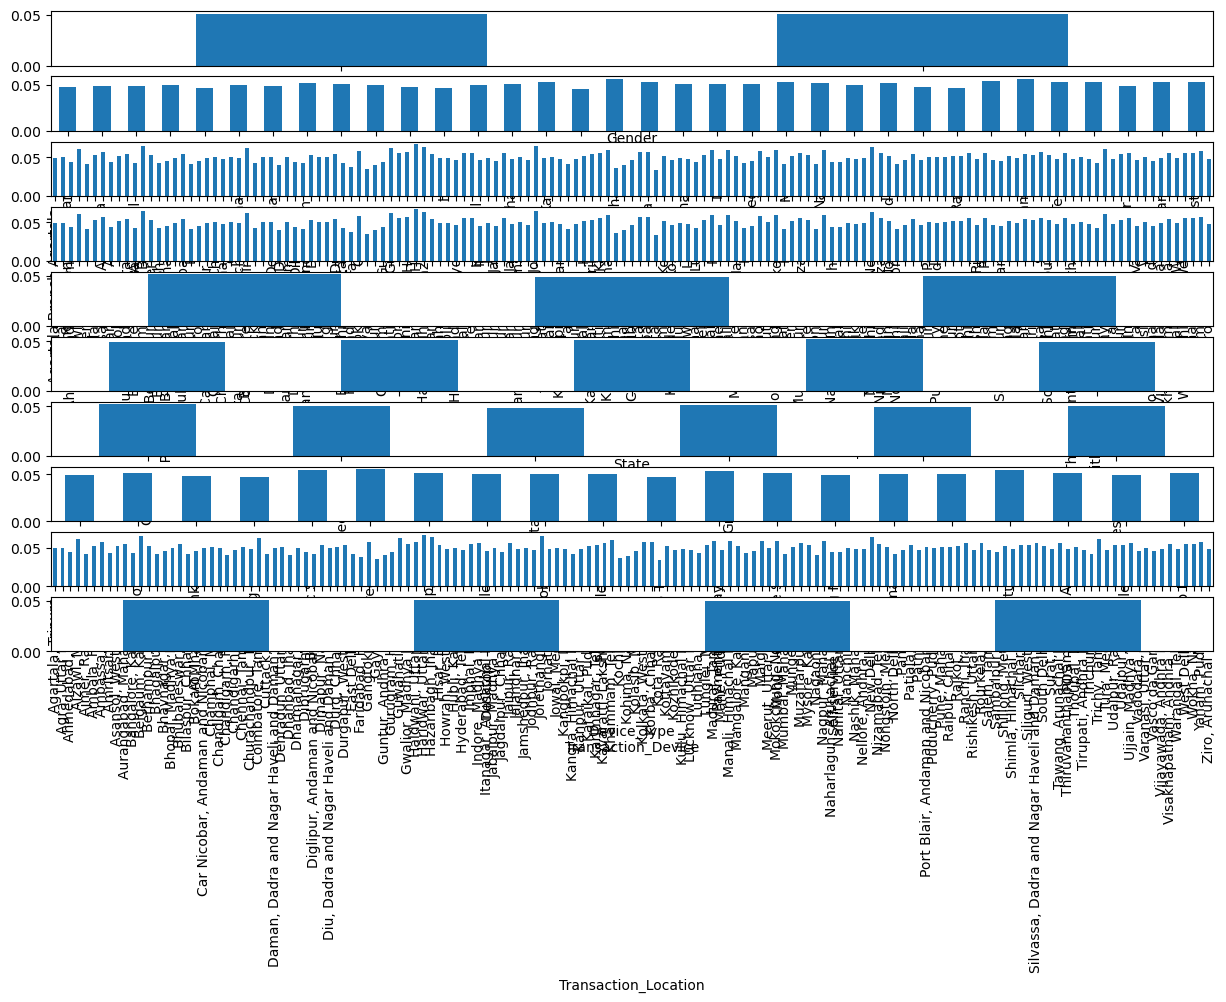

In [43]:
plt.figure(figsize=(15,10))
t=1
for i in cat_col:
    if i not in ['Transaction_Date','Transaction_Time','Transaction_Description']:
        plt.subplot(12,1,t)
        print(f"{i}",df.groupby(i)['Is_Fraud'].mean().plot(kind='bar'))
        print(pd.crosstab(df[i], df['Is_Fraud'], normalize='index').sort_values(by=1, ascending=False))
        print("-------------------------------------------------------------")
        t+=1

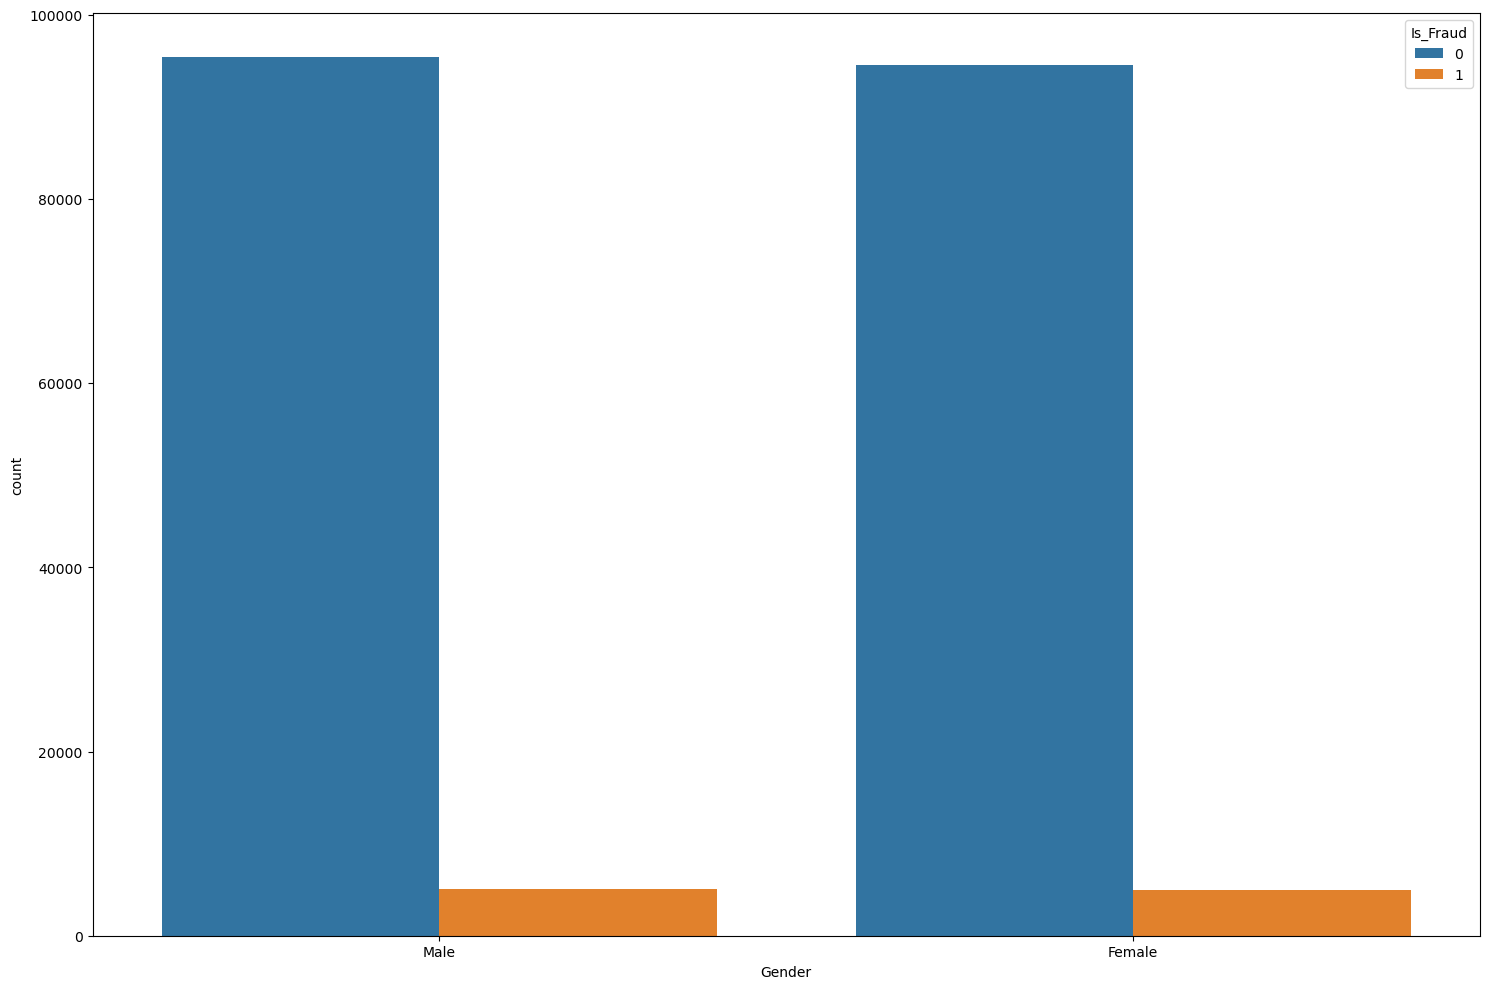

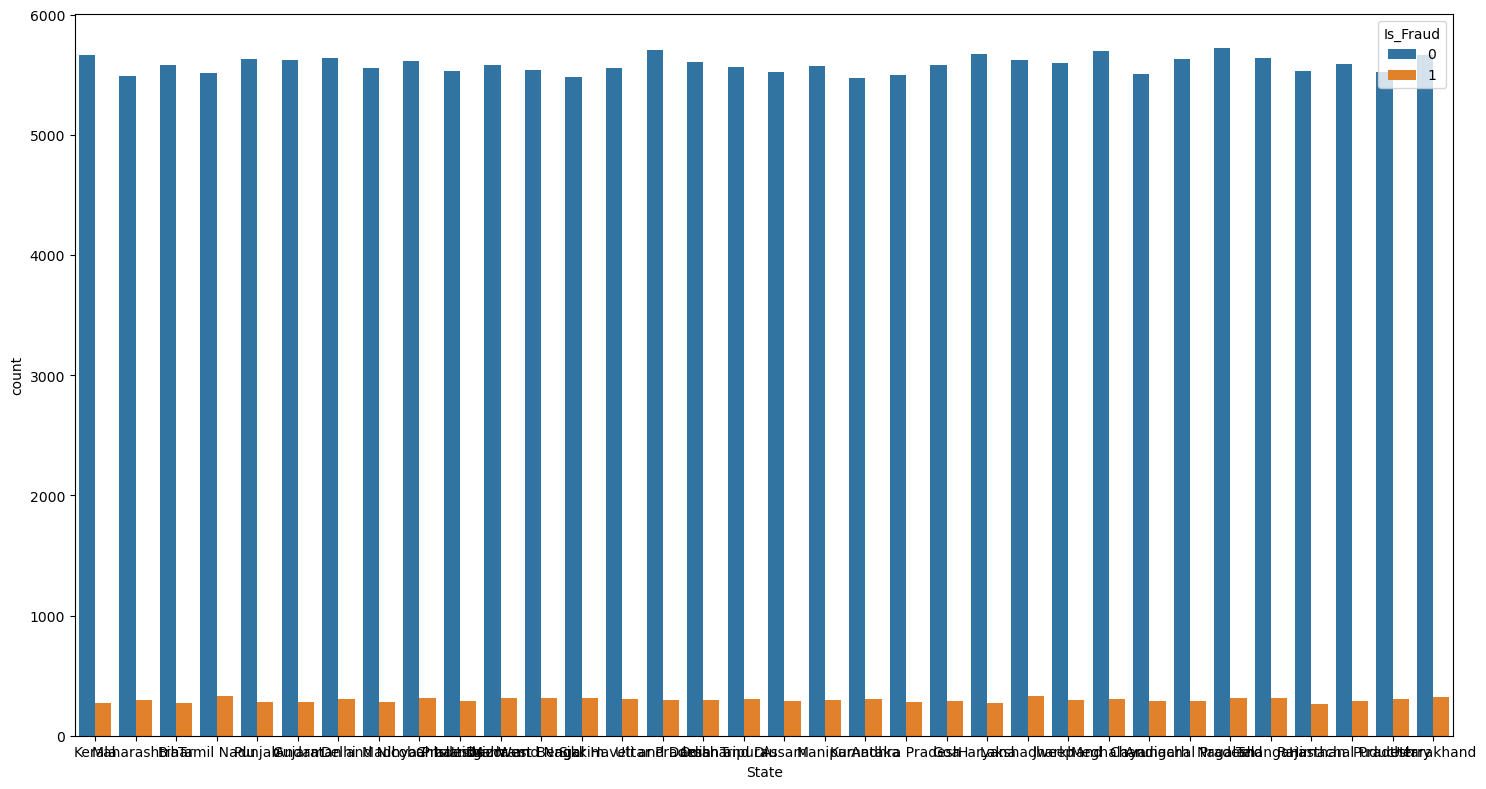

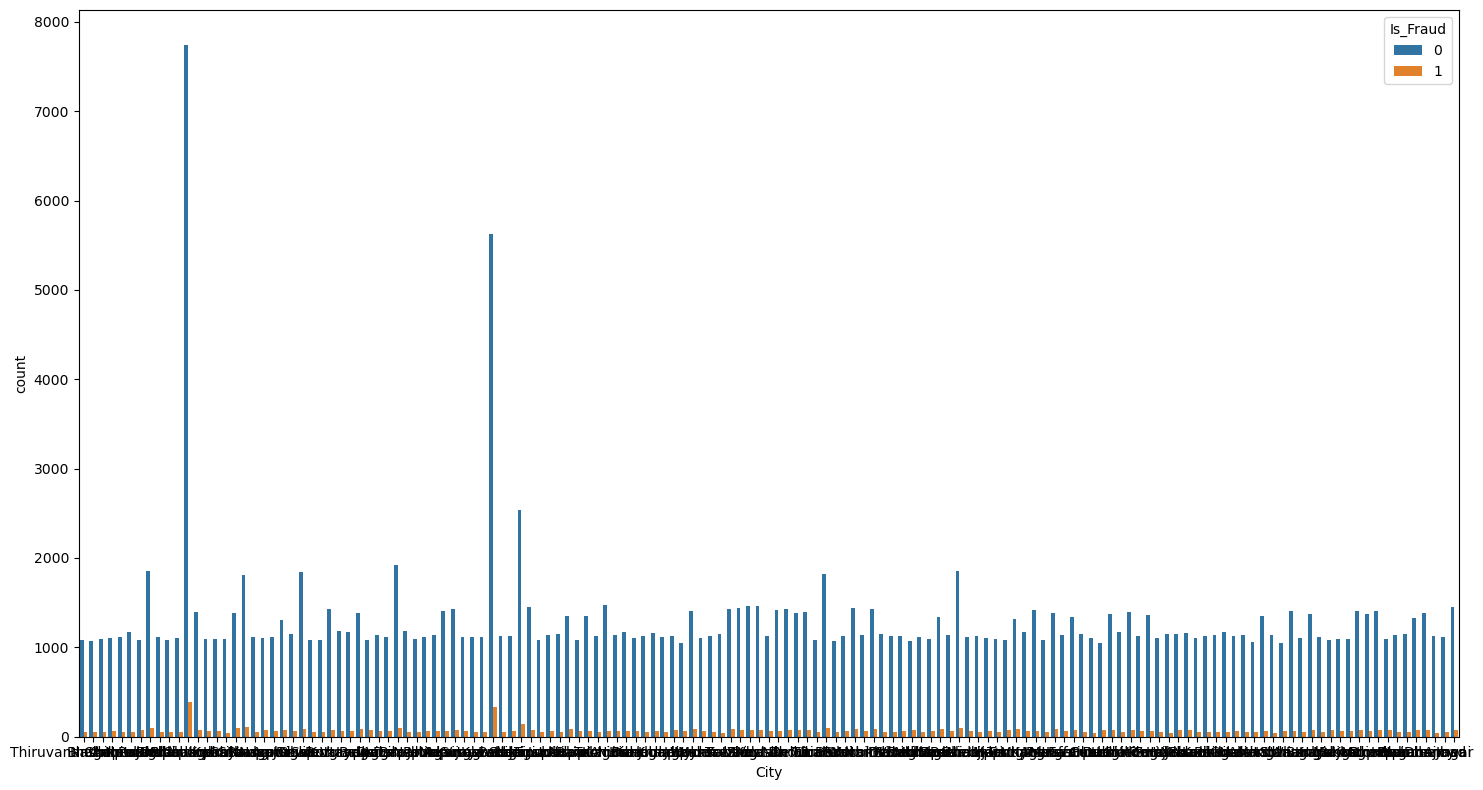

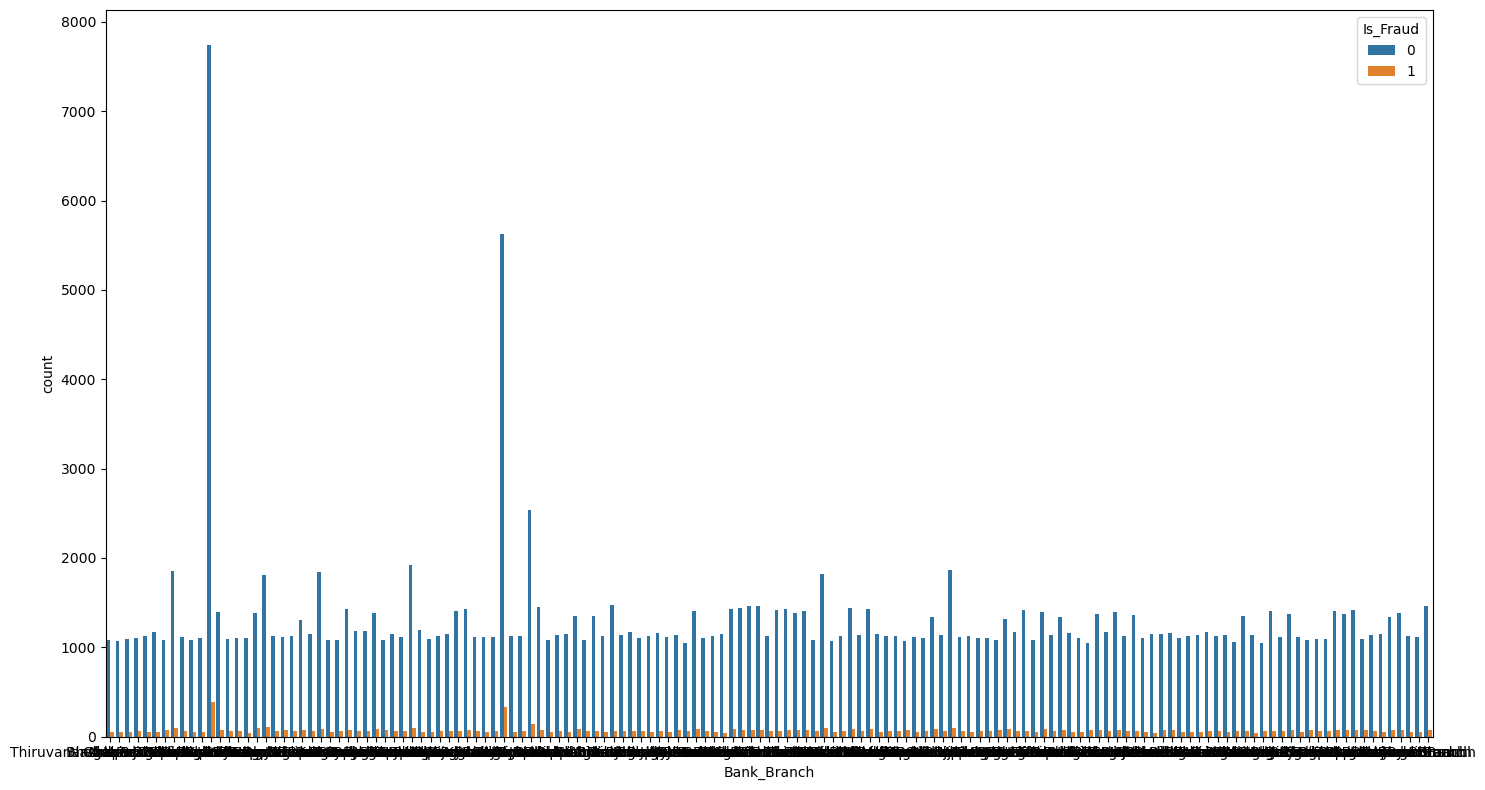

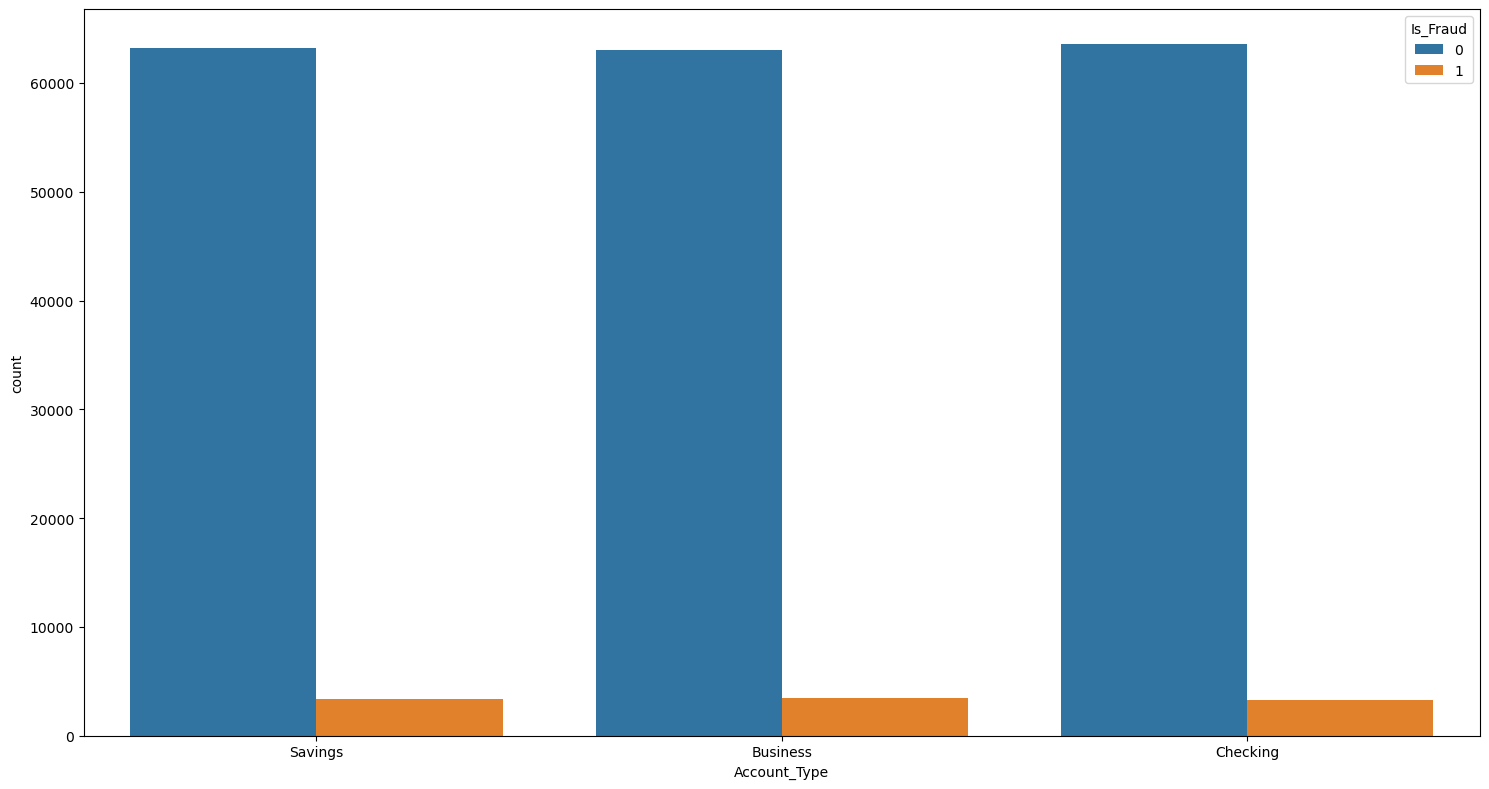

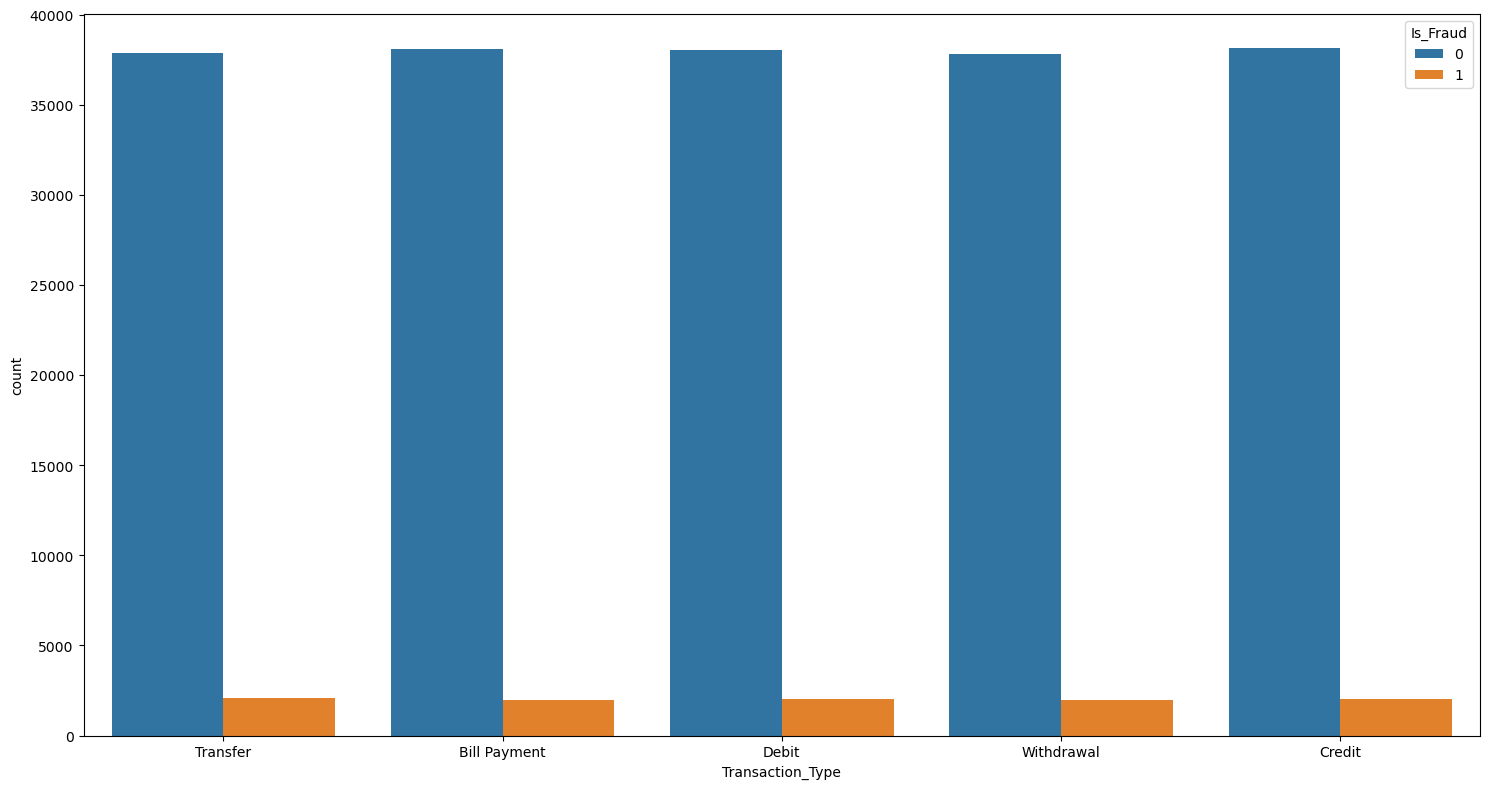

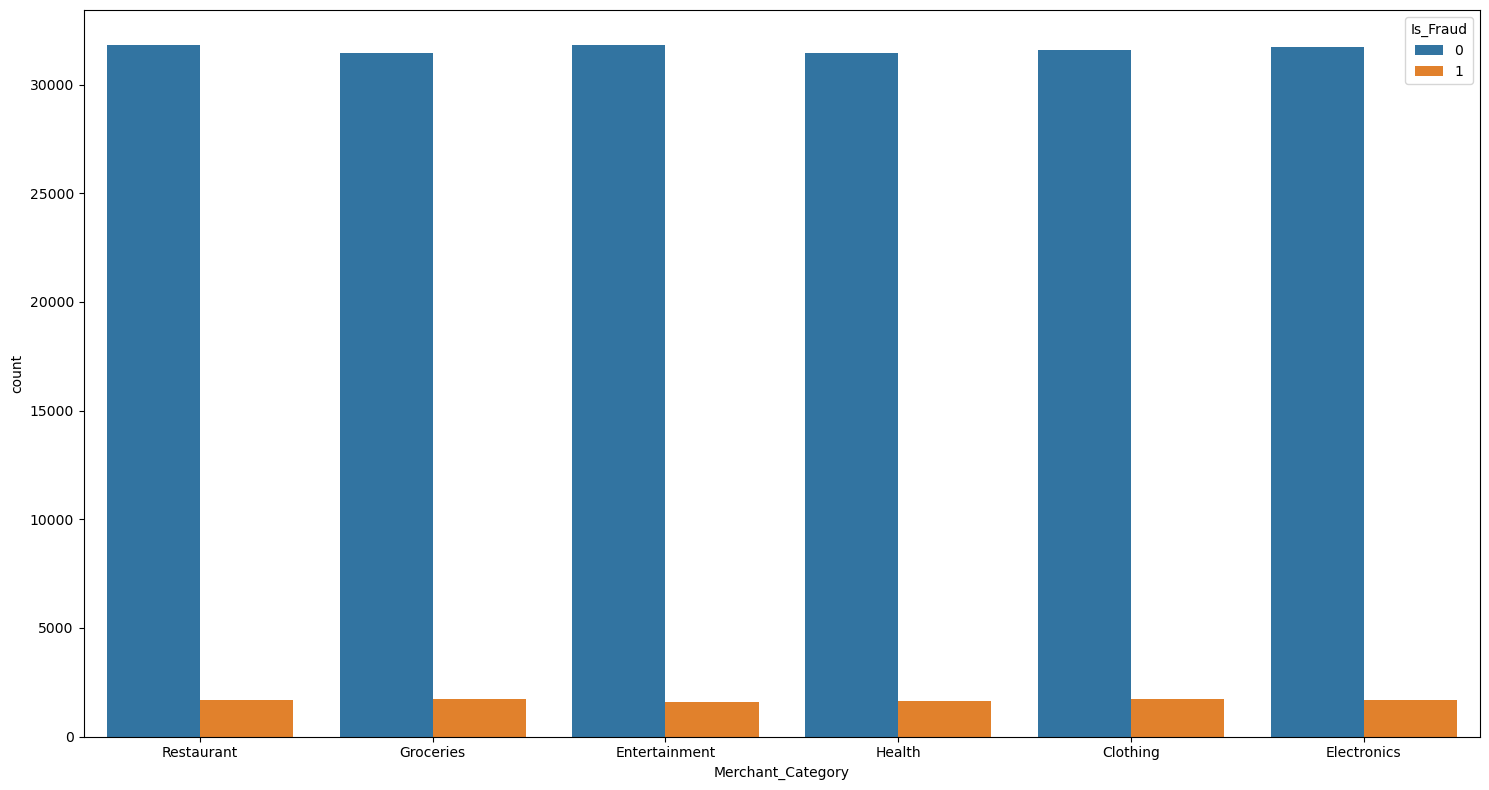

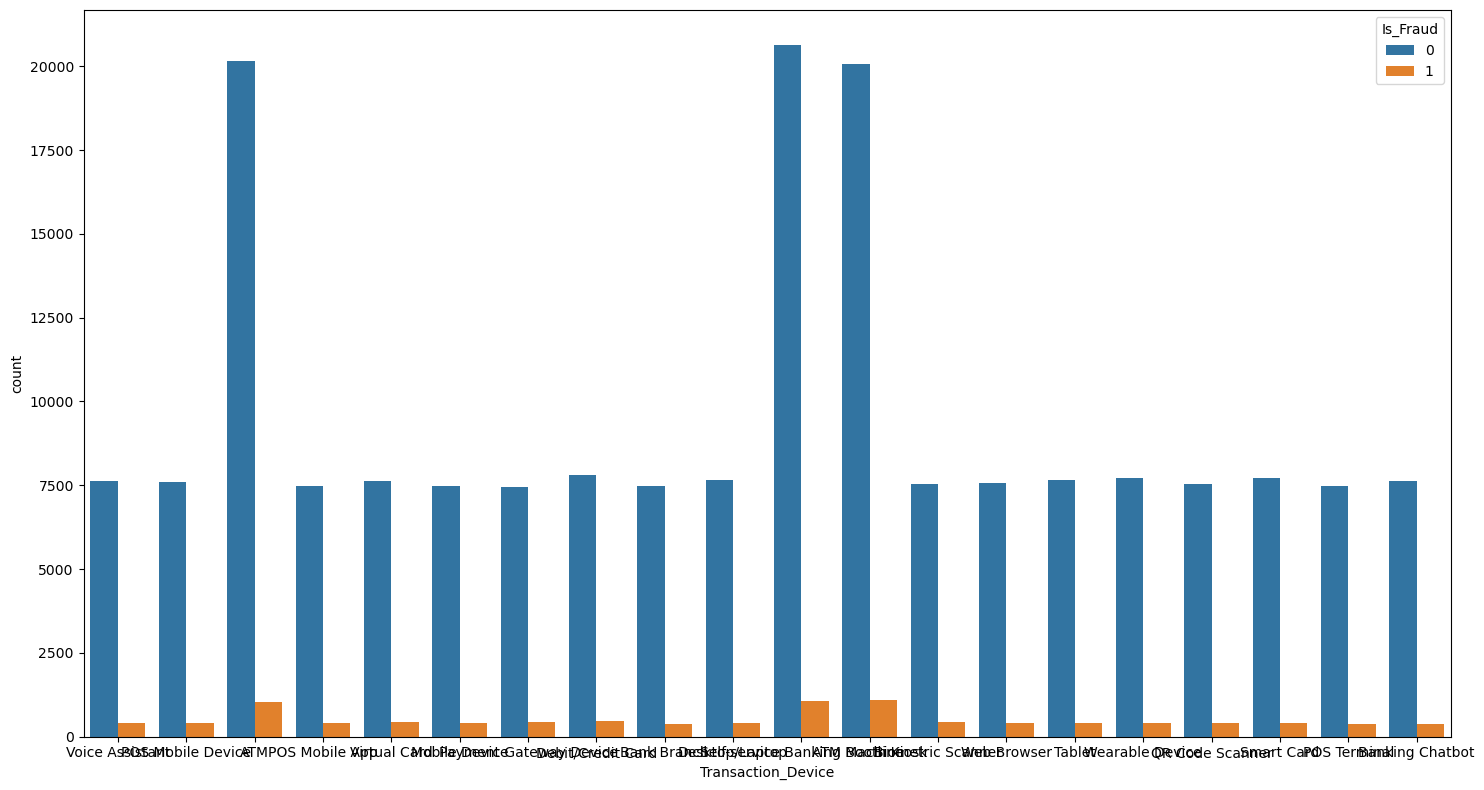

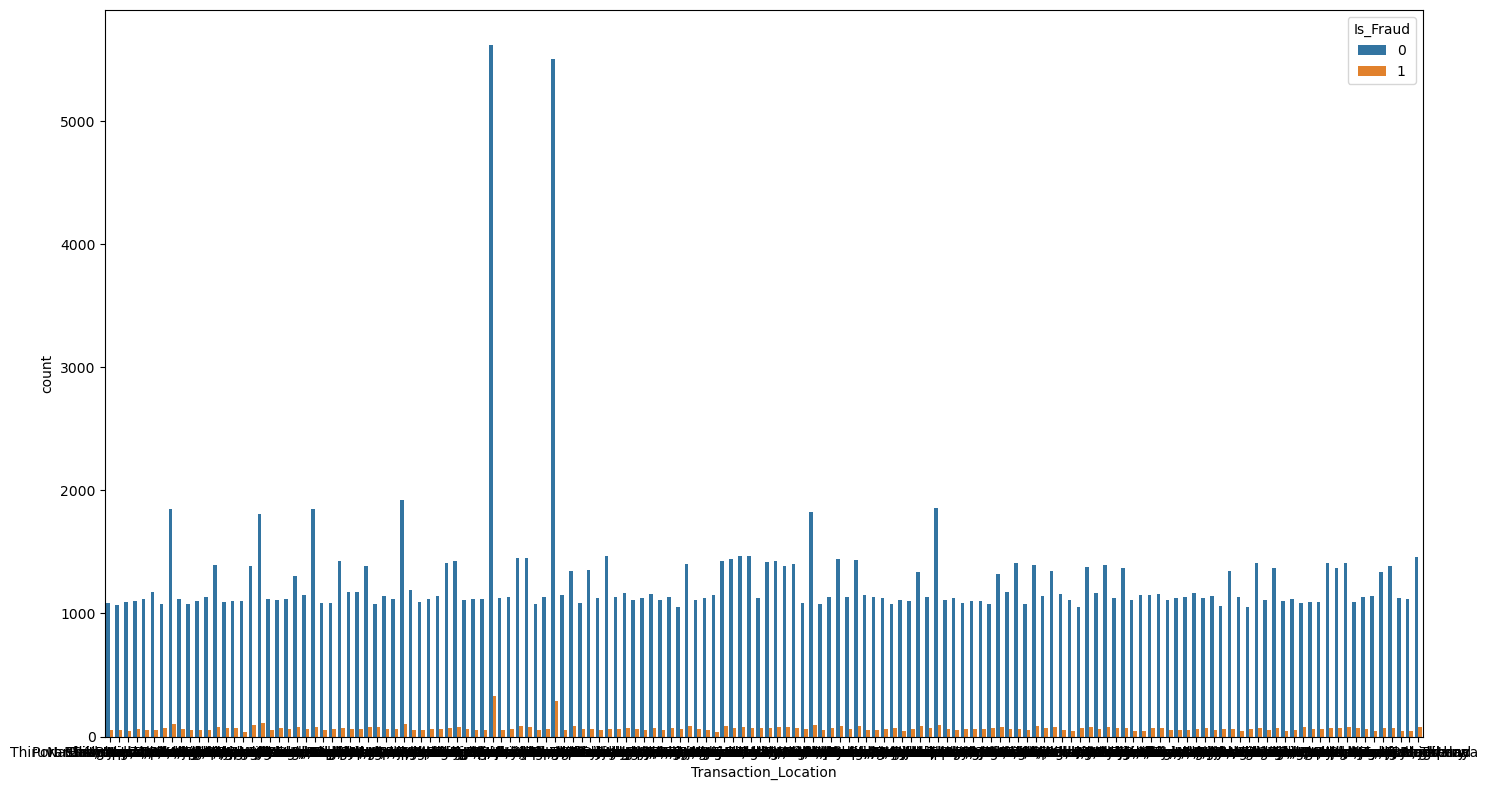

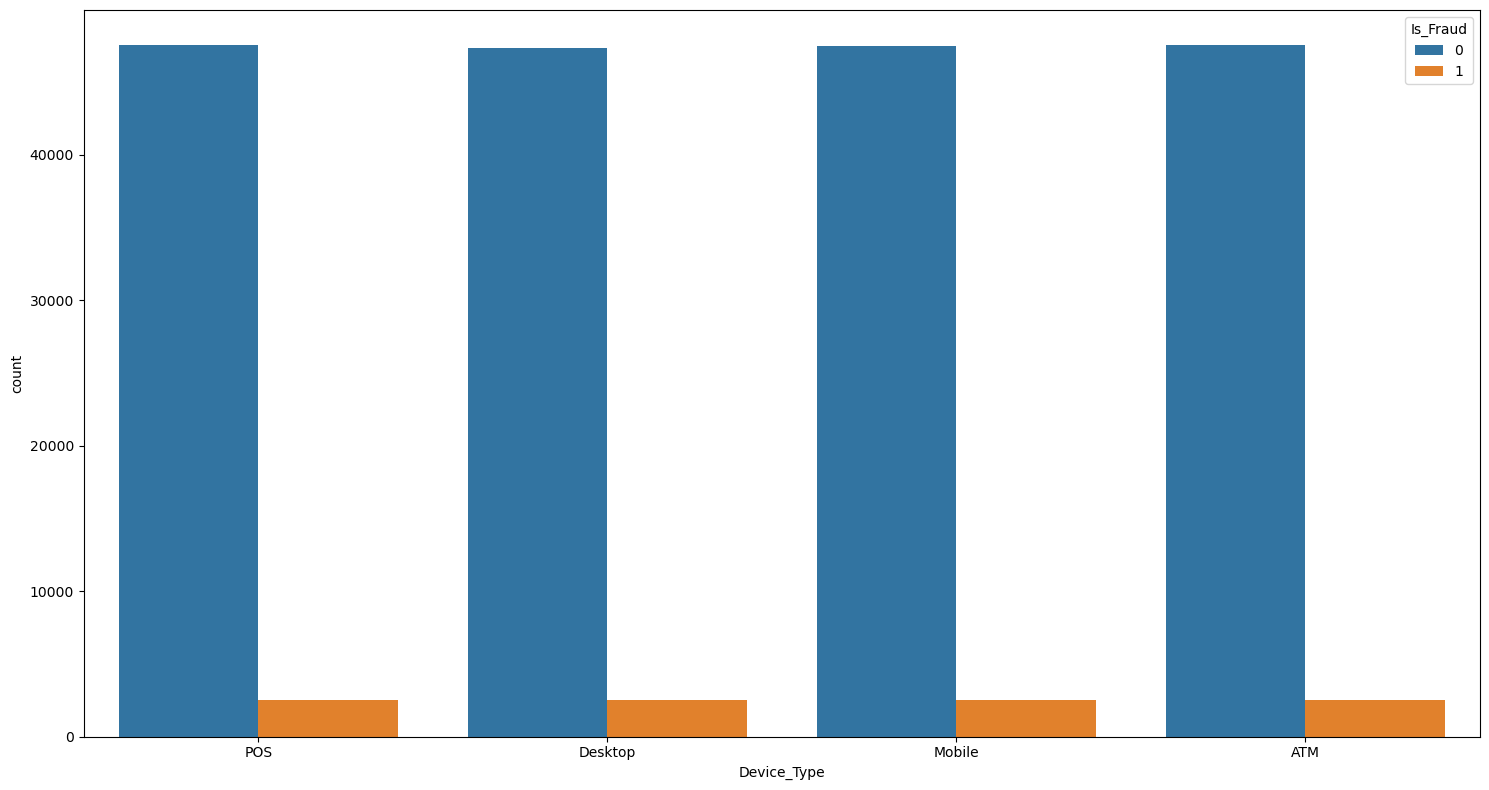

In [44]:
plt.figure(figsize=(15,10))
for i in cat_col:
    if i not in ['Transaction_Date','Transaction_Time','Transaction_Description']:
        sns.countplot(x=i, hue='Is_Fraud', data=df)
        plt.tight_layout()
        plt.show()

## Preprocessing

## Encoding

In [47]:
label_encoder = LabelEncoder()
for i in cat_col : 
    df[i] = label_encoder.fit_transform(df[i])

In [48]:
df.head()

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Description,day,hour,minute
0,1,60,15,127,127,2,32415.45,3,5,74557.27,17,129,3,0,9,23,16,4
1,0,51,18,100,100,0,43622.60,0,5,74622.66,9,102,1,0,65,11,17,14
2,1,20,4,13,13,2,63062.56,0,3,66817.99,0,13,1,0,102,25,3,9
3,0,57,28,22,22,0,14000.72,2,2,58177.08,8,24,2,0,51,19,12,27
4,0,43,25,7,7,2,18335.16,3,2,16108.56,16,7,2,0,37,30,18,30


In [49]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Gender                   200000 non-null  int32  
 1   Age                      200000 non-null  int64  
 2   State                    200000 non-null  int32  
 3   City                     200000 non-null  int32  
 4   Bank_Branch              200000 non-null  int32  
 5   Account_Type             200000 non-null  int32  
 6   Transaction_Amount       200000 non-null  float64
 7   Transaction_Type         200000 non-null  int32  
 8   Merchant_Category        200000 non-null  int32  
 9   Account_Balance          200000 non-null  float64
 10  Transaction_Device       200000 non-null  int32  
 11  Transaction_Location     200000 non-null  int32  
 12  Device_Type              200000 non-null  int32  
 13  Is_Fraud                 200000 non-null  int64  
 14  Tran

In [50]:
df.head()

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Description,day,hour,minute
0,1,60,15,127,127,2,32415.45,3,5,74557.27,17,129,3,0,9,23,16,4
1,0,51,18,100,100,0,43622.60,0,5,74622.66,9,102,1,0,65,11,17,14
2,1,20,4,13,13,2,63062.56,0,3,66817.99,0,13,1,0,102,25,3,9
3,0,57,28,22,22,0,14000.72,2,2,58177.08,8,24,2,0,51,19,12,27
4,0,43,25,7,7,2,18335.16,3,2,16108.56,16,7,2,0,37,30,18,30


## Modeling

## Random Forest

In [53]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
X = df.drop(columns=['Is_Fraud'])
y = df['Is_Fraud']

In [54]:
print("Shape for X Dataframe: ", X.shape)
print("Shape for y Dataframe: ", y.shape)

Shape for X Dataframe:  (200000, 17)
Shape for y Dataframe:  (200000,)


In [55]:
# Train the model
rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [56]:
# Get feature importances
feature_importances = pd.DataFrame(rf.feature_importances_, index=X.columns, columns=['importance'])
feature_importances = feature_importances.sort_values('importance', ascending=False)

<Figure size 1200x800 with 0 Axes>

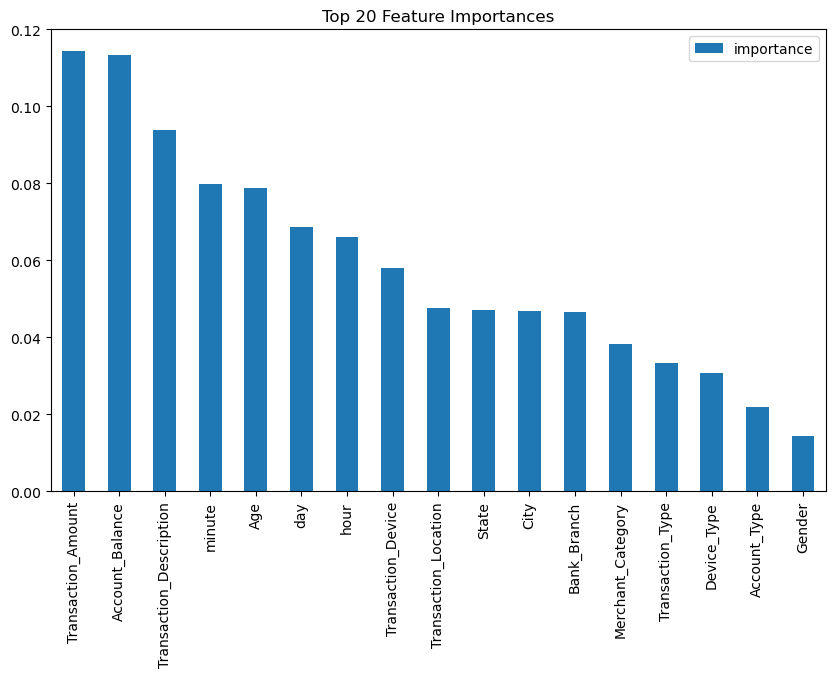

In [57]:
# Plot feature importances
plt.figure(figsize=(12, 8))
feature_importances.head(20).plot(kind='bar', figsize=(10, 6))
plt.title("Top 20 Feature Importances")
plt.show()

In [58]:
# use only important features
# Select features with importance greater than a threshold (e.g., 0.01)
important_features = feature_importances[feature_importances['importance'] > 0.01].index
X = df[important_features]
print("Shape for X Dataframe: ", X.shape)
print("Columns for X Dataframe: ", X.columns)

Shape for X Dataframe:  (200000, 17)
Columns for X Dataframe:  Index(['Transaction_Amount', 'Account_Balance', 'Transaction_Description',
       'minute', 'Age', 'day', 'hour', 'Transaction_Device',
       'Transaction_Location', 'State', 'City', 'Bank_Branch',
       'Merchant_Category', 'Transaction_Type', 'Device_Type', 'Account_Type',
       'Gender'],
      dtype='object')


## PCA (Principal Component Analysis)

In [60]:
# If the number of features is large, PCA can help reduce dimensions
pca = PCA(n_components=2)  # Reducing to 2 components for visualization
X_pca = pca.fit_transform(X)

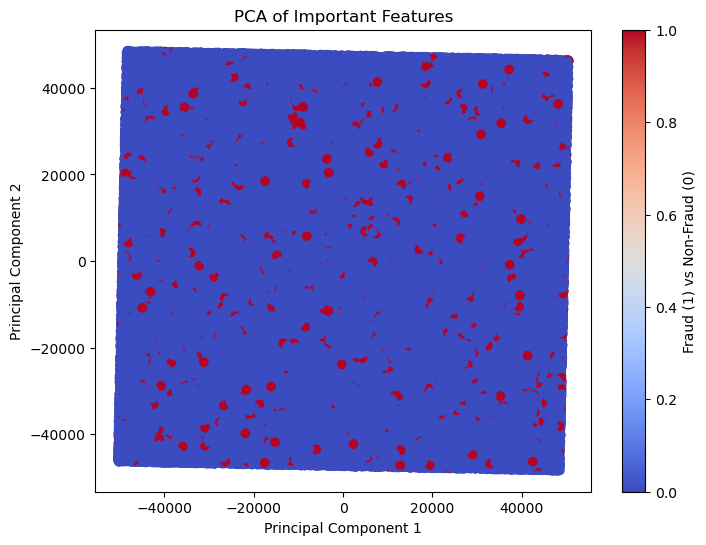

In [61]:
# Plot PCA results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm')
plt.title("PCA of Important Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Fraud (1) vs Non-Fraud (0)')
plt.show()

## Train-test Split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling

In [65]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training and Evaluation

In [67]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': xgb.XGBClassifier(),
    'LightGBM': lgb.LGBMClassifier(),
    'CatBoost': cb.CatBoostClassifier(silent=True),
    'AdaBoost': AdaBoostClassifier(),
    'Bagging': BaggingClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM (RBF)': SVC(kernel='rbf', probability=True),
    'SVM (Linear)': LinearSVC(),
    'GaussianNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Ridge Classifier': RidgeClassifier(),
}


In [68]:
# Define reduced parameter grids
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1],
        'solver': ['liblinear'],
        'penalty': ['l2']
    },
    'Decision Tree': {
        'max_depth': [5, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [10],
        'min_samples_split': [2],
        'min_samples_leaf': [1]
    },
    'Gradient Boosting': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [5]
    },
    'XGBoost': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [5],
        'subsample': [0.8, 1.0]
    },
    'SVM (RBF)': {
        'C': [1, 10],
        'gamma': ['scale', 'auto']
    },
    'SVM (Linear)': {
        'C': [1, 10],
    },
    'LightGBM': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [3, 5],
    },
    'CatBoost': {
        'iterations': [100],
        'learning_rate': [0.1],
        'depth': [3, 5]
    },
    'KNN': {
        'n_neighbors': [3],
        'weights': ['uniform', 'distance']
    },
    'AdaBoost': {
        'n_estimators': [100],
        'learning_rate': [0.01, 0.1]
    },
    'Bagging': {
        'n_estimators': [100],
        'max_samples': [0.8, 1.0]
    },
    'LDA': {},
    'QDA': {},
    'Ridge Classifier': {
        'alpha': [0.1, 1]
    },
    'GaussianNB': {}
}

In [ ]:
# Initialize an empty dictionary to store results
model_results = {}

# Handle class imbalance by computing class weights for each model that supports it
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("class_weight_dict: ", class_weight_dict)

# Handle SMOTE for class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Evaluate models with GridSearchCV
for model_name, model in models.items():
    print(f"Training model with GridSearchCV: {model_name}")
    
    # Get the parameter grid for the model
    param_grid = param_grids[model_name]
    
    # Modify model to include class weights where applicable
    if model_name in ['Logistic Regression', 'Random Forest', 'SVM (RBF)', 'SVM (Linear)']:
        # Assign class weights for models that support it
        if model_name == 'Logistic Regression':
            model = LogisticRegression(class_weight='balanced')
        elif model_name == 'Random Forest':
            model = RandomForestClassifier(class_weight='balanced')
        elif model_name in ['SVM (RBF)', 'SVM (Linear)']:
            model = SVC(probability=True, class_weight='balanced') if model_name == 'SVM (RBF)' else LinearSVC(class_weight='balanced')

    # Perform GridSearchCV with parallelism
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
    
    # Fit the model with the best parameters using the resampled data
    grid_search.fit(X_train_smote, y_train_smote)
    
    # Get the best model and its parameters
    best_model = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    
    # Predict on both train and test sets
    y_train_pred = best_model.predict(X_train_smote)
    y_test_pred = best_model.predict(X_test_scaled)
    
    # Store the results
    model_results[model_name] = {
        'train_accuracy': best_model.score(X_train_smote, y_train_smote),
        'test_accuracy': best_model.score(X_test_scaled, y_test),
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'classification_report': classification_report(y_test, y_test_pred),
        'roc_auc': roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1])
    }

    # Print results after all models are evaluated
    print("\nModel Evaluation Results:")
    #print(f"Model: {model_results[model_name]}\n")
    print(f"Train Accuracy: {model_results[model_name]['train_accuracy']:.4f}")
    print(f"Test Accuracy: {model_results[model_name]['test_accuracy']:.4f}")
    print(f"ROC AUC: {model_results[model_name]['roc_auc']:.4f}\n")
    print(f"Classification Report:\n{model_results[model_name]['classification_report']}")
    print("-" * 80)

class_weight_dict:  {0: 0.5264647235731161, 1: 9.946537361680965}
Training model with GridSearchCV: Logistic Regression
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

Model Evaluation Results:
Train Accuracy: 0.5113
Test Accuracy: 0.5064
ROC AUC: 0.4964

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.51      0.66     37955
           1       0.05      0.50      0.09      2045

    accuracy                           0.51     40000
   macro avg       0.50      0.50      0.38     40000
weighted avg       0.90      0.51      0.63     40000

--------------------------------------------------------------------------------
Training model with GridSearchCV: Decision Tree
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}



## Evaluation Results for All Models

In [ ]:
print("\nModel Evaluation Results:")
#print(f"Model: {model_results[model_name]}\n")
print(f"Train Accuracy: {model_results[model_name]['train_accuracy']:.4f}")
print(f"Test Accuracy: {model_results[model_name]['test_accuracy']:.4f}")
print(f"ROC AUC: {model_results[model_name]['roc_auc']:.4f}\n")
print(f"Classification Report:\n{model_results[model_name]['classification_report']}")
print("-" * 80)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Initialize a list to store results for all models
results_list = []

# Iterate through the models to collect results and plot confusion matrix and ROC curve
for model_name, model in model_results.items():
    # Extract the predicted values and actual values
    y_test_pred = model['y_test_pred']  # Use the predicted labels
    y_test = model['y_test']  # Actual true labels
    
    # Extract metrics
    train_accuracy = model['train_accuracy']
    test_accuracy = model['test_accuracy']
    roc_auc = model['roc_auc']
    
    # Classification Report
    clf_report = classification_report(y_test, y_test_pred)

    # Print the model name followed by its evaluation metrics
    print("-" * 40)
    print(f"Model: {model_name}")
    print("-" * 40)
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(clf_report)
    print("-" * 80)  # Separator line for clarity
    
    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_test_pred)
    roc_auc_value = auc(fpr, tpr)

    # Create subplots: 1 row, 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))  # Width, Height

    # Plot ROC Curve on the first subplot
    ax1.plot(fpr, tpr, color='b', lw=2, label=f'ROC curve (area = {roc_auc_value:.2f})')
    ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve for {model_name}')
    ax1.legend(loc='lower right')

    # Plot Confusion Matrix on the second subplot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'], ax=ax2)
    ax2.set_title(f'Confusion Matrix for {model_name}')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')

    # Show both plots
    plt.tight_layout()
    plt.show()

    # Append the results to the list for the DataFrame
    results_list.append({
        'Model': model_name,
        'Train Accuracy': f"{train_accuracy:.4f}",
        'Test Accuracy': f"{test_accuracy:.4f}",
        'ROC AUC': f"{roc_auc:.4f}",
        'Classification Report': clf_report
    })

# Convert results into a DataFrame for better presentation
results_df = pd.DataFrame(results_list)

# Print the summary of results in a tabular format
# print("\nSummary of Model Evaluation Results:")
# print(results_df.to_string(index=False))  # Display as a pretty table
print("-" * 80)
